In [1]:
import cobra
import re
import json
import sys
import os
from cobra import Reaction
from cameo import models
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx
from networkx.algorithms.community import greedy_modularity_communities

In [2]:
df_AB_all = pd.read_pickle('GSMGeneticDeterminants_bothdir.pkl')
genes_ALL = list(df_AB_all.index)

In [15]:
#需要敲除的基因列表
DES = pd.read_csv("E:\\1Mycount\\1111resort\\代谢模型\\cysK.csv",header=None,index_col=0)
genes_ALL = list(DES.index)


In [3]:
m = models.bigg.iML1515

# gene dictionaries for mapping between ID and names
gene_name_dic = {}
for g in m.genes:
    gene_name_dic[g.name] = g.id
    
gene_name_dic2 = {}
for g in m.genes:
    gene_name_dic2[g.id] = g.name

In [5]:
## FVA on glucose only
#设置通量条件
m = models.bigg.iML1515
m.reactions.EX_glc__D_e.bounds = (-10.0, 1000.0)
m.reactions.EX_o2_e.bounds = (-18.5, 1000.0)


        
for reaction in m.reactions:
    if reaction.bounds != (0.0, 0.0):
        if reaction.reversibility:
            reaction.bounds = (-1, 1)
        else:
            reaction.bounds = (0, 1)


In [16]:
#FVA计算
fva_res = {}

# compute for WT first
res = cobra.flux_analysis.flux_variability_analysis(m, fraction_of_optimum = 0.0, processes = 4)
fva_res['WT'] = res.to_dict()

for ind, gene in enumerate(genes_ALL):

    with m:
        m.genes.get_by_id(gene).knock_out()
        res = cobra.flux_analysis.flux_variability_analysis(m, fraction_of_optimum = 0.0, processes = 4)
    fva_res[gene] = res.to_dict()
    
    #with open('fva_res_m9.json', 'w') as fn:
    #    json.dump(fva_res, fn)

In [ ]:


# 1. 初始化结果字典
fva_res = {}

# 2. 计算野生型 (WT) 作为基准
# 注意：fraction_of_optimum=0.0 表示不考虑生长约束，计算的是物理上的最大可能范围
res_wt = cobra.flux_analysis.flux_variability_analysis(m, fraction_of_optimum=0.0, processes=4)
fva_res['WT'] = res_wt.to_dict()

# 3. 进行双基因同时敲除的 FVA
with m:
    # 连续敲除列表中的所有基因（这里只有2个）
    for gene_id in genes_ALL:
        m.genes.get_by_id(gene_id).knock_out()
    
    # 在双敲除的状态下运行 FVA
    res_double = cobra.flux_analysis.flux_variability_analysis(m, fraction_of_optimum=0.0, processes=4)
    
    # 记录结果，键名可以自定义，例如 'Double_KO'
    fva_res['Double_KO'] = res_double.to_dict()

# 此时 m 已经自动恢复到野生型状态

In [22]:
#结果储存
with open('E:\\1Mycount\\1111resort\\代谢模型\\fva_shuanggene.json', 'w') as fn:
        json.dump(fva_res, fn)

In [23]:
#读取
import json
with open('E:\\1Mycount\\1111resort\\代谢模型\\fva_shuanggene.json', 'r') as fn:
    FVA_res_ALL = json.load(fn)

In [30]:
# 使用字典推导式快速构建，避免 count 计数错误
span_dict = {}
for strain, res in FVA_res_ALL.items():
    df_res = pd.DataFrame.from_dict(res)
    # 计算通量宽度 (maximum - minimum)
    span_dict[strain] = df_res['maximum'] - df_res['minimum']

FVA_res = pd.DataFrame(span_dict)
reactions = FVA_res.index.tolist()

# 2. 筛选结果表 (IF_genes289)
# 修改逻辑：只要列名是 WT，或者是你敲除的基因（单敲或双敲），都包含进来
selected_cols = ['WT']
for col in FVA_res.columns:
    # 检查列名是否包含你定义的 gene ID
    if any(g in col for g in genes_ALL):
        if col not in selected_cols:
            selected_cols.append(col)

IF_genes289 = FVA_res[selected_cols]

# 3. 筛选受影响的反应
edges = []
wt_span = IF_genes289['WT']

for gene_col in IF_genes289.columns:
    if gene_col == 'WT' or gene_col == 's0001':
        continue
    
    # 获取显示的节点名称
    try:
        # 如果是单基因 ID (如 b2414)，获取其 Name (如 cysK)
        node_name = m.genes.get_by_id(gene_col).name
    except:
        # 如果是双基因组合 (如 b2414___b2421)，直接用 ID 字符串
        node_name = gene_col 

    current_span = IF_genes289[gene_col]
    
    for i in range(len(reactions)):
        # 阈值判断
        if wt_span.iloc[i] > 0.01: # 野生型该反应有通量
            ratio = current_span.iloc[i] / wt_span.iloc[i]
            if ratio < 0.95: # 敲除后通量范围显著缩小（比如降为0）
                edges.append((node_name, reactions[i]))

# 4. 构建图
if len(edges) == 0:
    print("警告：没有发现受影响的反应。请检查：1. 双敲除是否成功；2. fraction_of_optimum 是否设为 1.0")
else:
    print(f"成功找到 {len(edges)} 条受影响的 基因-反应 关系。")
    G = nx.Graph()
    G.add_edges_from(edges)
    d = dict(nx.degree(G))

警告：没有发现受影响的反应。请检查：1. 双敲除是否成功；2. fraction_of_optimum 是否设为 1.0


In [33]:
# 看看双敲除后的通量宽度是否真的发生了变化
print(IF_genes289.loc['CYSS']) # 查看半胱氨酸合成反应
# 1. 检查双敲除的列名到底叫什么
print("JSON中的所有列名:", list(FVA_res_ALL.keys()))


WT    1.0
Name: CYSS, dtype: float64
JSON中的所有列名: ['WT', 'Double_KO']


In [34]:

# 2. 检查双敲除后 CYSS 到底有没有变 0 (假设双敲除 ID 是 'b2414___b2421')
# 请根据上面的输出修改键名
double_ko_id = 'Double_KO' 
if double_ko_id in FVA_res:
    print(f"双敲除 {double_ko_id} 下 CYSS 的 Span 为:", FVA_res.loc['CYSS', double_ko_id])
else:
    print("列名匹配失败，请检查双敲除的键名格式")

双敲除 Double_KO 下 CYSS 的 Span 为: 0.0


In [40]:
import pandas as pd
import networkx as nx

# 1. 提取 span 数据
span_dict = {}
for strain, res in FVA_res_ALL.items():
    df_temp = pd.DataFrame.from_dict(res)
    span_dict[strain] = df_temp['maximum'] - df_temp['minimum']

FVA_res = pd.DataFrame(span_dict)
reactions = FVA_res.index.tolist()

# 2. 筛选我们要对比的列
# 既然你的 JSON 里叫 'Double_KO'，我们手动指定它
analyze_cols = ['WT', 'Double_KO'] 
IF_genes_final = FVA_res[analyze_cols]

# 3. 建立边（Edges）
edges = []
nodes1 = []
nodes2 = []
wt_span = IF_genes_final['WT']
ko_span = IF_genes_final['Double_KO']

for i in range(len(reactions)):
    # 只要 WT 下有通量（>0.01），且双敲除后范围缩减了 5% 以上
    if wt_span.iloc[i] > 0.01:
        ratio = ko_span.iloc[i] / wt_span.iloc[i]
        if ratio < 0.95:
            # 记录：双敲除这个动作，影响了反应 reactions[i]
            edges.append(('CysK/CysM_DoubleKO', reactions[i]))
            nodes2.append(reactions[i])

nodes1 = ['CysK/CysM_DoubleKO']
nodes2 = list(set(nodes2))
# 4. 构建网络
G = nx.Graph()
G.add_nodes_from(nodes1 + nodes2)
G.add_edges_from(edges)

if len(edges) > 0:
    print(f"成功捕捉到 {len(edges)} 条受影响的反应边！")
    # 看看受影响最大的前 10 个反应是什么
    d = dict(nx.degree(G))
    sorted_reactions = sorted([n for n in G.nodes() if n in reactions], 
                              key=lambda x: d[x], reverse=True)
    print("受影响最严重的反应示例:", sorted_reactions[:10])
else:
    print("依然没有边，请检查 ratio 计算。")

成功捕捉到 25 条受影响的反应边！
受影响最严重的反应示例: ['MTAN', 'HSST', 'SHSL1', 'GTHRDtex', 'EX_5mtr_e', 'EX_gthrd_e', 'MTHFR2', 'CGLYtex', 'METS', 'CYSTL']


In [24]:
#基因的反应通量计算
reactions = []
for r in m.reactions:
    reactions.append(r.id)
FVA_res = pd.DataFrame(index = reactions)

count = 0
for strain, res in FVA_res_ALL.items():
    results = pd.DataFrame.from_dict(res)
 #   flux_span = pd.DataFrame(results.subtract([0,results['minimum']])['maximum'])
    flux_span = pd.DataFrame(results['maximum']).subtract(results['minimum'], axis=0)
    if strain != 'WT':
        FVA_res.insert(count, column = strain, value = flux_span.values)
    else:
        FVA_res.insert(count, column = strain, value = flux_span.values)
        count += 1

In [25]:
IF_genes289 = pd.DataFrame(index = reactions)

IF_genes289.insert(0, column = 'WT', value = FVA_res['WT'])
count = 1
for col in FVA_res.columns:
    if col in genes_ALL:
        IF_genes289.insert(count, column = col, value = FVA_res[col])
        count += 1

In [13]:
#结果筛选
edges = []
for gene in IF_genes289.columns:
    if gene != 's0001':
        for ind, i in enumerate(IF_genes289[gene]):
            if IF_genes289['WT'][ind] > IF_genes289[gene][ind]:
                 if IF_genes289['WT'][ind] > 0.01:
                    if IF_genes289[gene][ind]/IF_genes289['WT'][ind] < 0.95:
                        edges.append((m.genes.get_by_id(gene).name, IF_genes289['WT'].index[ind]))


# turn into graph
nodes1 = []
nodes2 = []
for edge in edges:
    nodes1.append(edge[0])
    nodes2.append(edge[1])         
nodes1 = list(set(nodes1))
nodes2 = list(set(nodes2))

G = nx.Graph()
G.add_nodes_from(nodes1+nodes2)
G.add_edges_from(edges)
# get the degree
d = nx.degree(G)

In [41]:
print('Number of gene nodes:', len(nodes1))
print('Number of metabolite nodes:', len(nodes2))

Number of gene nodes: 1
Number of metabolite nodes: 25


In [42]:
c = list(greedy_modularity_communities(G))         #聚类的代谢簇

In [44]:
# 贪婪模块算法聚类
gene_name_dic3 = {}
for g in m.genes:
    gene_name_dic3[g.name] = g.name
nx.set_node_attributes(G, gene_name_dic3, name = 'labels')

node_colors = {}

# colour code each metabolite in the network according to the cluster they have been assigned to
for met in nodes2:
    for ind, cluster in enumerate(c):
        if met in c[ind]:
            node_colors[met] = str(ind)
        
for gene in nodes1:
    for ind, cluster in enumerate(c):
        if gene in c[ind]:
            node_colors[gene] = str(ind)
    
#nx.draw(G, with_labels=True)
#plt.show()
# Save the network
nx.set_node_attributes(G, node_colors, name='color')
 #nx.write_gml(G, 'E:\\1Mycount\\1111结果-总\\代谢模型\\Bipartite_FVA_newGreedy_bothdir.gml')
nx.write_gml(G, 'E:\\1Mycount\\1111resort\\matlab\\shuanggene.gml')

In [45]:
subsystems = []   #获取所有反应的子系统
for i in m.reactions:
    subsystems.append(i.subsystem)
subsystems = list(set(subsystems))


reacs = []
for r in m.reactions:
    reacs.append(r.id)      ## 提取反应 ID
df_reacs_sss_all = pd.DataFrame(index = reacs)

count = 0          #构建反应-子系统映射矩阵
for s in subsystems:
 
    s_genes = []
    for r in m.reactions:
        r_s = 0        
        if r.subsystem in s:

            r_s = 1
        s_genes.append(r_s)
    
    df_reacs_sss_all.insert(count, column = s, value = s_genes)      #df_reacs_sss_all 形成一个反应-子系统二进制矩阵
    count += 1

In [46]:
df_reacs_c = pd.DataFrame(index = reacs)      #储存簇与反应的对应关系
for ind, i in enumerate(c):
    col = []
    count = 0
    for node in reacs:
        if node in c[ind]:
            col.append(1)
        else:
            col.append(0)
    df_reacs_c.insert(count, column = ind, value = col)    
    count += 1
            
        
df_c_sss = df_reacs_c.T.dot(df_reacs_sss_all).T       #代谢簇与子系统的联系


0

corrected significance:
Methionine Metabolism, p = 4.651530017828307e-07, FDR = 0.00025
Cysteine Metabolism, p = 5.29061193042559e-06, FDR = 0.0005
Arginine and Proline Metabolism, p = 0.000372036464006959, FDR = 0.00075
Biomass and maintenance functions, p = 0.0004841231963734325, FDR = 0.001


<Axes: >

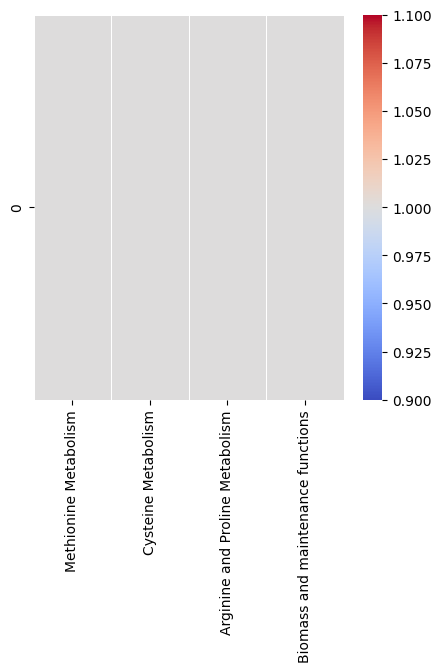

In [47]:
from scipy import stats                #超几何检验  
sig_pathways_clusters40 = {}

for ind, cluster_id in enumerate(c):
    genes = []
    genes_pathway = {}
    if len(c[ind]) > 5.0:
        
        print('')
        print(ind)
        nodes_list = []
        for i in c[ind]:
            if i in nodes2:
                nodes_list.append(i)


        

            if i in nodes1:
                genes.append(i)

        p_value = []
        p_val_name = []
        for s in subsystems:
            
            x = df_c_sss[ind][s]
            M = df_reacs_sss_all.sum(axis = 0)[s]
            df_c_sss[ind]
            #print(ind, s, x, M)
            if M != 0.0 and x != 0.0:
                p = stats.hypergeom.sf(x, len(m.reactions), M, len(nodes_list))
            else:
                p = 1.0
                
                
            genes_path = []
            for ind_reac, reac in enumerate(df_reacs_sss_all[s]):
                if reac > 0:
                    if df_reacs_sss_all.index[ind_reac] in c[ind]:
                        reaction = df_reacs_sss_all.index[ind_reac]
                        genes = G.neighbors(reaction)
                        for ge in genes:
                            if ge in c[ind]:
                                genes_path.append(ge)
            genes_pathway[s] = list(set(genes_path))

                
                
            


            #if p < 0.05:
            #    print(ind, s, x, M, p)
                #if p < 0.05:
                #    print(ss, p)

            p_value.append(p)
            p_val_name.append(s)
        print('')       
        print('corrected significance:')       

        
        
        sig_pathways_clusters40[ind] = {}
        from operator import itemgetter
        indices, pval_sorted = zip(*sorted(enumerate(p_value), key=itemgetter(1)))
        sig_pathways = []
        for indj, i in enumerate(pval_sorted):
            if i < ((indj+1)/40)*0.01:
                sig_pathways.append(p_val_name[indices[indj]])
                sig_pathways_clusters40[ind].update({p_val_name[indices[indj]] : genes_pathway[p_val_name[indices[indj]]]})
                print(f"{p_val_name[indices[indj]]}, p = {i}, FDR = {((indj+1)/40)*0.01}")                  #多重假设检验矫正
                #print(p_val_name[indices[indj]])
                #print(((indj+1)/40)*0.01)
                #print(genes_pathway[p_val_name[indices[indj]]])
        if sig_pathways == []:
                sig_pathways_clusters40[ind] = {}
#输出热图
plt.figure(figsize=(5, 5))
sns.heatmap(
    pd.DataFrame.from_dict(sig_pathways_clusters40, orient="index").fillna(0).astype(bool),
    cmap="coolwarm", cbar=True, linewidths=0.5
)


In [48]:
#biocyc数据库中获取途径与反应的关系
reac_pathways = pd.read_excel('date/Reaction_pathways.xlsx', sheet_name='Sheet1')
reac_pathways2 = pd.read_excel('date/Reaction_pathways2.xlsx', sheet_name='Sheet1')

In [49]:
reaction_pathways = {}           #模型反应与途径对应
for i in m.reactions:
    pathways = []
    if 'biocyc' in i.annotation:
        for ind, reac in enumerate(reac_pathways['Reaction']):
            if i.annotation['biocyc'][0].split('META:')[1] == reac:
                #print(i, met_pathways2['Pathways of compound'][ind])
                if str(reac_pathways2['Pathways of a reaction'][ind]) != 'nan':
                    pathways = reac_pathways2['Pathways of a reaction'][ind].split(' // ')
    reaction_pathways[i.id] = pathways
pathways = []
for i, j in reaction_pathways.items():
    for path in j:
        pathways.append(path)
        
pathways = list(set(pathways))
len(pathways)          #与模型中反应对应的途径，数目     247条

247

In [50]:
#如果反应本身没有 BioCyc 注释，则利用 基因信息推导代谢途径，
gene_pathways = pd.read_excel('date/Gene_pathways2.xlsx', sheet_name='Sheet1')

In [51]:
for i in m.genes:
    if i.id != 's0001':
        for ind, gene in enumerate(gene_pathways['column 1']):
            if gene_name_dic2[i.id] in gene:
                if str(gene_pathways['Pathways of gene'][ind]) != 'nan':
                    for r in m.genes.get_by_id(i.id).reactions:
                        if reaction_pathways[r.id] == []:
                            reaction_pathways[r.id] = gene_pathways['Pathways of gene'][ind].split(' // ')
for i, j in reaction_pathways.items():
    for path in j:
        pathways.append(path)       #为基因相关的反应赋予代谢途径
        
pathways = list(set(pathways))
len(pathways)                       #396条

396

0

corrected significance:
L-methionine biosynthesis I, p = 0.0, FDR = 2.5252525252525256e-05


<Axes: >

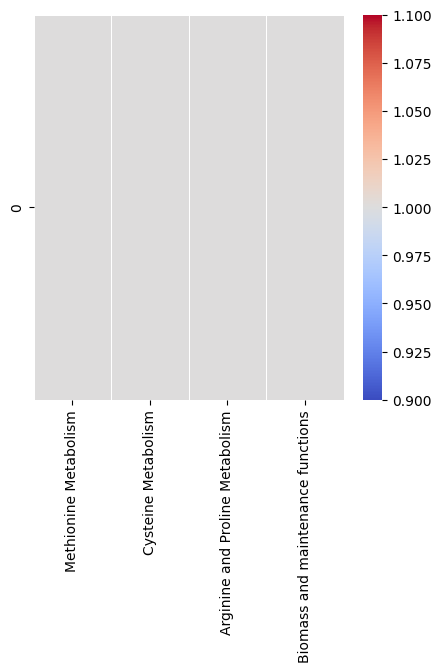

In [52]:
# get significance

sig_pathways_clusters = {}
for ind, cluster in enumerate(c):
    if len(c[ind]) > 10.0:
        print(ind)
        p_value = []
        p_val_name = []
        genes_pathway = {}
        for i in pathways:
            number_reacs_ml = 0.0
            number_reacs_model = 0.0
            genes_path = []
            for reac, j in reaction_pathways.items():
                for path in j:
                    if i == path:
                        if reac in c[ind]:
                            number_reacs_ml += 1.0
                            for ge in nodes1:
                                if (ge, reac) in edges:
                                    if ge in c[ind]:
                                        genes_path.append(ge)

                        if reac in m.reactions:
                            number_reacs_model += 1.0


            l_c = 0.0
            for reac in c[ind]:
                if reac in nodes2:
                    l_c += 1.0
            if number_reacs_ml > 3.0:                #聚类中该代谢途径的反应数大于 3，才进行统计检验
                p = stats.hypergeom.sf(number_reacs_ml, len(m.reactions), number_reacs_model, l_c)
                #if p < 0.05:
                    #print(i, p, number_reacs_ml, number_reacs_model)

                p_value.append(p)
                p_val_name.append(i)
                genes_pathway[i] = list(set(genes_path))

            else:
                p_value.append(1.0)
                p_val_name.append(i)


        print('')       
        print('corrected significance:')       

        sig_pathways_clusters[ind] = {}
        from operator import itemgetter
        indices, pval_sorted = zip(*sorted(enumerate(p_value), key=itemgetter(1)))
        for indj, i in enumerate(pval_sorted):
            if i < ((indj+1)/396)*0.01:
                print(f"{p_val_name[indices[indj]]}, p = {i}, FDR = {((indj+1)/396)*0.01}")
                #print(((indj+1)/396)*0.01)
                sig_pathways_clusters[ind].update({p_val_name[indices[indj]] : genes_pathway[p_val_name[indices[indj]]]})
                #print(genes_pathway[p_val_name[indices[indj]]])
#输出热图
plt.figure(figsize=(5, 5))
sns.heatmap(
    pd.DataFrame.from_dict(sig_pathways_clusters40, orient="index").fillna(0).astype(bool),
    cmap="coolwarm", cbar=True, linewidths=0.5
)


In [53]:
# Merge the groups

#Readily available and abundant host unsaturated fatty acids, such as oleate, can circumvent inactivating mutations in these pathways, making unsaturated fatty acid synthesis a target that is unlikely to receive much attention in the drug discovery field.


    
# group some of the pathways

grouped_sig_pathways = {}
grouped_sig_pathways['Proline metabolism'] = ['L-proline biosynthesis I (from L-glutamate)', 'Arginine and Proline Metabolism']
grouped_sig_pathways['Fatty acid degradation'] = ['fatty acid &beta;-oxidation I (generic)',
                                                 'oleate &beta;-oxidation']
grouped_sig_pathways['Purine metabolism'] = ['superpathway of purine nucleotides <i>de novo</i> biosynthesis II',
                                              'guanosine ribonucleotides <i>de novo</i> biosynthesis',
                                              'superpathway of guanosine nucleotides <i>de novo</i> biosynthesis II',
                                              'superpathway of histidine, purine, and pyrimidine biosynthesis',
                                              'superpathway of guanine and guanosine salvage', 
                                               'adenine and adenosine salvage III', 
                                               'guanine and guanosine salvage III',
                                               'guanine and guanosine salvage',
                                               'xanthine and xanthosine salvage',
                                               'adenine and adenosine salvage II',
                                               'adenine and adenosine salvage V',
                                               'guanosine deoxyribonucleotides <i>de novo</i> biosynthesis II',
                                               "inosine-5'-phosphate biosynthesis I",
                                               "purine ribonucleosides degradation",
                                             "adenosine nucleotides degradation II",
                                             "guanosine nucleotides degradation III"
                                             "purine deoxyribonucleosides degradation I",
                                             "superpathway of purine deoxyribonucleosides degradation",
                                             "superpathway of purine nucleotides <i>de novo</i> biosynthesis II",
                                             "adenosine ribonucleotides <i>de novo</i> biosynthesis",
                                             "purine deoxyribonucleosides degradation I",
                                             "guanosine nucleotides degradation III",
                                             "superpathway of adenosine nucleotides <i>de novo</i> biosynthesis II",
                                             "5-aminoimidazole ribonucleotide biosynthesis I",
                                             '5-aminoimidazole ribonucleotide biosynthesis II',
                                             'superpathway of 5-aminoimidazole ribonucleotide biosynthesis',
                                             "Nucleotide Salvage Pathway", 
                                             'adenosine deoxyribonucleotides <i>de novo</i> biosynthesis II'
                                             
                                              ]


grouped_sig_pathways['Folate metabolism'] = ['superpathway of tetrahydrofolate biosynthesis', 
                                            '6-hydroxymethyl-dihydropterin diphosphate biosynthesis I',
                                            'folate transformations III (<i>E. coli</i>)',
                                            'tetrahydrofolate biosynthesis', 'folate polyglutamylation', 'Folate Metabolism']



grouped_sig_pathways['Energy carriers biosynthesis'] = ['NAD salvage pathway I', 
                                                        'flavin biosynthesis I (bacteria and plants)',
                                                       'NAD salvage pathway IV (from nicotinamide riboside)',
                                                       'NAD salvage pathway I (PNC VI cycle)',
                                                       '2-carboxy-1,4-naphthoquinol biosynthesis', 
                                                       'superpathway of ubiquinol-8 biosynthesis (early decarboxylation)',
                                                       'superpathway of menaquinol-8 biosynthesis I',
                                                       'glutathione-glutaredoxin redox reactions',
                                                       'ubiquinol-8 biosynthesis (early decarboxylation)']

grouped_sig_pathways['Nucleic acid processing'] = ['tRNA processing', 'tRNA-uridine 2-thiolation and selenation (bacteria)',
                                                  'queuosine biosynthesis I (<i>de novo</i>)']


grouped_sig_pathways['Peptidoglycan metabolism'] = ['muropeptide degradation', 
                                                    'peptidoglycan biosynthesis I (<I>meso</I>-diaminopimelate containing)',
                                                    'UDP-<i>N</i>-acetylmuramoyl-pentapeptide biosynthesis I (<i>meso</i>-diaminopimelate containing)',
                                                    'anhydromuropeptides recycling I', 'peptidoglycan maturation (<i>meso</i>-diaminopimelate containing)', 'Murein Biosynthesis',
                                                    'Murein Recycling',
                                                    
                                                   ]

grouped_sig_pathways['Fatty acid and lipid biosynthesis'] = ['fatty acid biosynthesis initiation III', '(5Z)-dodecenoate biosynthesis I',
                                                            'fatty acid biosynthesis initiation (type II)', 'superpathway of unsaturated fatty acids biosynthesis (<i>E. coli</i>)',
                                                            'superpathway of fatty acid biosynthesis initiation (E. coli)', '(Kdo)<sub>2</sub>-lipid A biosynthesis I (E. coli)',
                                                             'fatty acid elongation -- saturated', 'palmitoleate biosynthesis I (from (5Z)-dodec-5-enoate)', 'fatty acid biosynthesis initiation II',
                                                            'superpathway of fatty acid biosynthesis I (E. coli)', '<i>cis</i>-vaccenate biosynthesis', 'palmitate biosynthesis (type II fatty acid synthase)', 'Membrane Lipid Metabolism']

grouped_sig_pathways['Pyrimidine metabolism'] = ['salvage pathways of pyrimidine deoxyribonucleotides', 
                                                'superpathway of pyrimidine ribonucleosides salvage',
                                                'superpathway of pyrimidine deoxyribonucleotides <i>de novo</i> biosynthesis',
                                                'salvage pathways of pyrimidine ribonucleotides',
                                                 'pyrimidine deoxyribonucleosides degradation',
                                                 'pyrimidine deoxyribonucleotide phosphorylation',
                                                 'pyrimidine deoxyribonucleotides <i>de novo</i> biosynthesis I',
                                                 'superpathway of pyrimidine deoxyribonucleosides degradation',
                                                 'pyrimidine ribonucleosides salvage I',
                                                 'superpathway of pyrimidine deoxyribonucleotides <i>de novo</i> biosynthesis (<i>E. coli</i>)',
                                                 'pyrimidine deoxyribonucleotides dephosphorylation',
                                                 'pyrimidine deoxyribonucleotides <i>de novo</i> biosynthesis II',
                                                 'pyrimidine nucleobases salvage I',
                                                 'pyrimidine ribonucleosides salvage III',
                                                 'pyrimidine ribonucleosides salvage II',
                                                 'pyrimidine nucleobases salvage II',
                                                 'CMP phosphorylation', 
                                                 'superpathway of pyrimidine ribonucleotides <i>de novo</i> biosynthesis',
                                                 'pyrimidine ribonucleosides degradation',
                                                 'superpathway of pyrimidine nucleobases salvage',
                                                 'UMP biosynthesis I',
                                                 'uracil degradation III'
                                                                                                 ]

grouped_sig_pathways['Lipolysaccharides metabolism'] = ['superpathway of lipopolysaccharide biosynthesis',
                                                        'lipid A-core biosynthesis (<i>E. coli</i> K-12)',
                                                        'superpathway of (Kdo)<SUB>2</SUB>-lipid A biosynthesis',
                                                        'Kdo transfer to lipid IV<sub>A</sub> I (E. coli)',
                                                        'lipid IV<sub>A</sub> biosynthesis (E. coli)',
                                                        'polymyxin resistance', 'Lipopolysaccharide Biosynthesis / Recycling',
                                                       ]

grouped_sig_pathways['Enterobactin metabolism'] = ['enterobacterial common antigen biosynthesis', 
                                                   'enterobactin biosynthesis']

grouped_sig_pathways['Carrier biosynthesis'] = ['acyl carrier protein metabolism']


grouped_sig_pathways['Heme metabolism'] = ['heme <i>b</i> biosynthesis II (oxygen-independent)', 
                                          'heme <i>b</i> biosynthesis V (aerobic)',
                                          'superpathway of heme <i>b</i> biosynthesis from uroporphyrinogen-III',
                                           'cytochrome <i>c</i> biogenesis (system I type)'
                                          ]
grouped_sig_pathways['Chorismate metabolism'] = ['superpathway of chorismate metabolism', 'chorismate biosynthesis from 3-dehydroquinate']

grouped_sig_pathways['Electron transport chain'] = ['hydrogen to fumarate electron transfer', 'NADH to fumarate electron transfer', 'NADH to hydrogen peroxide electron transfer']
grouped_sig_pathways['Phospholipid metabolism'] = ['superpathway of phospholipid biosynthesis I (bacteria)', 'CDP-diacylglycerol biosynthesis I', 'cardiolipin biosynthesis III', 'CDP-diacylglycerol biosynthesis II', 'Glycerophospholipid Metabolism',
                                                  'phosphatidylserine and phosphatidylethanolamine biosynthesis I',]
grouped_sig_pathways["Pyridoxal 5'-phosphate biosynthesis"] = ["superpathway of pyridoxal 5'-phosphate biosynthesis and salvage",
                                                              "pyridoxal 5'-phosphate salvage I"]

grouped_sig_pathways['Sugar nucleotide biosynthesis'] = ['UDP-&alpha;-D-galactose biosynthesis', 
                                                        'UDP-<i>N</i>-acetyl-&alpha;-D-mannosaminouronate biosynthesis',
                                                        'galactose degradation I (Leloir pathway)',
                                                        'dTDP-&beta;-L-rhamnose biosynthesis',
                                                        'UDP-&alpha;-D-glucuronate biosynthesis (from UDP-glucose)',
                                                         'dTDP-<i>N</i>-acetylthomosamine biosynthesis',
                                                        '<i>O</i>-antigen building blocks biosynthesis (<i>E. coli</i>)',
                                                        'ADP-L-<i>glycero</i>-&beta;-D-<i>manno</i>-heptose biosynthesis',
                                                         'CMP-3-deoxy-D-<I>manno</I>-octulosonate biosynthesis']
grouped_sig_pathways['Allantoin degradation'] = ['allantoin degradation IV (anaerobic)', 'allantoin degradation to glyoxylate III']
grouped_sig_pathways['putrescine degradation'] = ['putrescine degradation II']

grouped_sig_pathways['Sulfur compound metabolism'] = ['assimilatory sulfate reduction I', 'superpathway of sulfate assimilation and cysteine biosynthesis']

grouped_sig_pathways['Tetrapyrrole biosynthesis'] = ['tetrapyrrole biosynthesis I (from glutamate)']
grouped_sig_pathways['Biotin metabolism'] = ['biotin biosynthesis I', 'biotin biosynthesis from 8-amino-7-oxononanoate I']
grouped_sig_pathways['Autoinducer AI-2 biosynthesis'] = ['autoinducer AI-2 biosynthesis I']


grouped_sig_pathways['Tyrosine, Tryptophan, and Phenylalanine Metabolism'] = ['Tyrosine, Tryptophan, and Phenylalanine Metabolism', 'L-tyrosine biosynthesis I', 'L-tryptophan biosynthesis',]
grouped_sig_pathways['Cysteine metabolism'] = ['L-cysteine biosynthesis VII (from <i>S</i>-sulfo-L-cysteine)', 'Cysteine Metabolism', 'L-cysteine degradation II']
grouped_sig_pathways['Histidine metabolism'] = ['Histidine metabolism', 'L-histidine biosynthesis', 'Histidine Metabolism']

grouped_sig_pathways['Arginine metabolism'] = ['L-arginine degradation II (AST pathway)', 'L-arginine biosynthesis I (via L-ornithine)']
grouped_sig_pathways['Glycerol degradation'] = ['glycerophosphodiester degradation', 'glycerol and glycerophosphodiester degradation']
grouped_sig_pathways['Lipoate biosynthesis'] = ['lipoate biosynthesis', 'lipoate biosynthesis and incorporation I']
grouped_sig_pathways['Methionine metabolism'] = ['L-methionine biosynthesis I', 'Methionine Metabolism']
grouped_sig_pathways['Lysine and threonine metabolism'] = ['L-lysine biosynthesis I', 'Threonine and Lysine Metabolism',]
grouped_sig_pathways['Nitrogen metabolism'] = ['Nitrogen Metabolism']
grouped_sig_pathways['Methylerythritol phosphate pathway'] = ['methylerythritol phosphate pathway I']
grouped_sig_pathways['Oxidative phosphorylation'] = ['Oxidative Phosphorylation']
grouped_sig_pathways['Pentose phosphate pathway'] = ['Pentose Phosphate Pathway',]
grouped_sig_pathways['Cell envelope biosynthesis'] = ['Cell Envelope Biosynthesis',]
grouped_sig_pathways['Aspartate metabolism'] = ['aspartate superpathway',]
grouped_sig_pathways['tRNA charging'] = ['tRNA Charging']
grouped_sig_pathways['Transport metabolism'] = ['Extracellular exchange','Transport, Outer Membrane Porin',
'Inorganic Ion Transport and Metabolism',
'Transport, Outer Membrane',
'Transport, Inner Membrane',]
grouped_sig_pathways['S-adenosyl-L-methionine salvage I'] = ['<i>S</i>-adenosyl-L-methionine salvage I']
grouped_sig_pathways['Arsenate detoxification (glutaredoxin)'] = ['arsenate detoxification II (glutaredoxin)']
grouped_sig_pathways['Glycine and serine metabolism'] = ['glycine biosynthesis I', 'Glycine and Serine Metabolism','L-serine biosynthesis I', 'superpathway of L-serine and glycine biosynthesis I']
grouped_sig_pathways['Cofactor metabolism'] = ['Cofactor and Prosthetic Group Biosynthesis',]
grouped_sig_pathways['8-amino-7-oxononanoate biosynthesis'] = ['8-amino-7-oxononanoate biosynthesis I']
grouped_sig_pathways['Leucine and Isoleucine Metabolism'] = ['L-isoleucine biosynthesis I (from threonine)','L-leucine biosynthesis', 'Valine, Leucine, and Isoleucine Metabolism']


grouped_sig_pathways['Pentose phosphate pathway'] = ['pentose phosphate pathway (non-oxidative branch) I']

In [54]:
# 合并簇对应的40与biocyc的途径
sig_pathways = []
for ind, data in sig_pathways_clusters.items():
    for path, genes in data.items():
        match = 0
        for group, pathways in grouped_sig_pathways.items():
            if path in pathways:
                match = 1
                sig_pathways.append(group)
        if match == 0:
            sig_pathways.append(path)
sig_pathways = list(set(sig_pathways))




for ind, data in sig_pathways_clusters40.items():
    for path, genes in data.items():
        match = 0
        for group, pathways in grouped_sig_pathways.items():
            if path in pathways:
                match = 1
                sig_pathways.append(group)
        if match == 0:
            sig_pathways.append(path)
sig_pathways = list(set(sig_pathways))

In [55]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

    
# Biocyc sig.
edges_sp = []
for C_ind, data in sig_pathways_clusters.items():
    for pathway, genes in sig_pathways_clusters[C_ind].items():
        match = 0.0
        for group, p in grouped_sig_pathways.items():
            if pathway in p:
                path_new = group
                match = 1.0
            
        if match == 0.0:
            path_new = pathway

        for gene in genes:
            edges_sp.append((path_new, gene))
            
        
        
        

            
            
# Bigg pathways sig. 

for C_ind, data in sig_pathways_clusters40.items():
    for pathway, genes in sig_pathways_clusters40[C_ind].items():
        match = 0.0
        for group, p in grouped_sig_pathways.items():
            if pathway in p:
                path_new = group
                match = 1.0
            
        if match == 0.0:
            path_new = pathway
        print(C_ind, path_new, genes)
        print('')

        for gene in genes:
            edges_sp.append((path_new, gene))
            
nodes1_sp = []# pathways
nodes2_sp = []# genes
for i, j in edges:
    nodes1_sp.append(i)
    nodes2_sp.append(j)
    
nodes1_sp = list(set(nodes1_sp))
nodes2_sp = list(set(nodes2_sp))


G3 = nx.Graph()
G3.add_nodes_from(nodes1_sp+nodes2_sp)
G3.add_edges_from(edges_sp)



# colour code each gene in the network according to the cluster they have been assigned to
for gene in nodes1_sp:
    for ind, cluster in enumerate(c):
        if gene in c[ind]:
            G3.add_node(gene, color = str(ind))

                
nx.write_gml(G3, '131.gml') 

0 Methionine metabolism ['CysK/CysM_DoubleKO']

0 Cysteine metabolism ['CysK/CysM_DoubleKO']

0 Proline metabolism ['CysK/CysM_DoubleKO']

0 Biomass and maintenance functions ['CysK/CysM_DoubleKO']

